# Introduction to Convolutional Neural Networks, part 1

We will start looking at image classification, the task of training a model to classify an image into one of a pre-set number of categories. The image below shows common computer vision tasks and is from [Shivani Kolungade](https://medium.com/@kolungade.s/object-detection-image-classification-and-semantic-segmentation-using-aws-sagemaker-e1f768c8f57d)

![Image classification, object detection and segmentation by Shivani Kolungade](images/classification_detection_segmentation.png)


## Image classification of an American Sign Language Dataset

For this exercise, we will explore image classification, starting with a "simple" neural network and then adding convolutional layers, data augmentation and more to build better models.

This notebook is inspired by the Nvidia [Fundamentals of Deep Learning](https://www.nvidia.com/en-us/training/instructor-led-workshops/fundamentals-of-deep-learning/) (instructor-led)/ [Getting Started with Deep Learning](https://courses.nvidia.com/courses/course-v1:DLI+S-FX-01+V1/about) (online, asynchronous) exercises. 

## American Sign Language Dataset

The American Sign Language [manual alphabet](https://en.wikipedia.org/wiki/American_manual_alphabet) has signs for each letter. We will skip J and Z because those signs require motion. 

The dataset we'll use is from [Kaggle](https://www.kaggle.com/arjaiswal/sign-mnist-using-cnn/data). There should be 24 classes--Note that in the dataset, the classes are labeled 0-8 and 10-24, skipping the 9 for J. That causes some issues with the function that converts these to categorical. So, we'll lie and say there are 25 classes.

We'll start with this dataset because it helps with the transition from the tabular data we've been working with to image data. Images are a grid of pixels, where each pixel has a brightness. For greyscale images, there is one grid, for color images, there are typically three grids for the red, green and blue colors (RGB), often called color channels.

Let's start by loading the data and examining some images.

## Load the data and examine some images

In [1]:
import numpy as np
import pandas as pd

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
%matplotlib inline

import os 
os.environ['KERAS_BACKEND'] = 'torch'
import keras

from keras.models import Sequential
from keras.layers import Dense

from helpers_plot_history import plot_history # A function to plot training history. 
                            # We 1st used the code in 15_neural_networks.ipynb. 

In [2]:
sign_train = pd.read_csv("data/sign_mnist/sign_mnist_train.csv")
sign_test = pd.read_csv("data/sign_mnist/sign_mnist_test.csv")

In [3]:

sign_train.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [4]:
# .values gives the whole row as an array for each column
# 7172 rows in total

y_train = sign_train['label']
X_train = sign_train.drop(columns='label').values

y_test = sign_test['label']
X_test = sign_test.drop(columns='label').values

X_test.shape

(7172, 784)

In [5]:
# Just to show that there are no samples in class 9
sign_train.groupby('label').size()

label
0     1126
1     1010
2     1144
3     1196
4      957
5     1204
6     1090
7     1013
8     1162
10    1114
11    1241
12    1055
13    1151
14    1196
15    1088
16    1279
17    1294
18    1199
19    1186
20    1161
21    1082
22    1225
23    1164
24    1118
dtype: int64

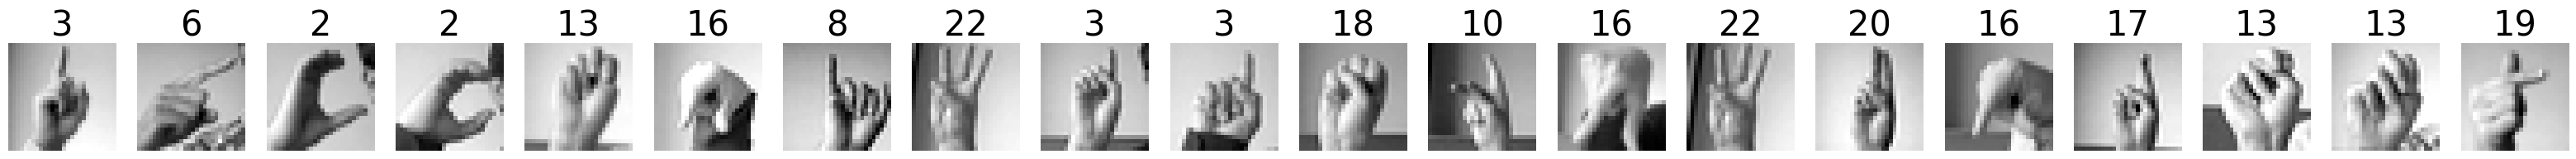

In [6]:
plt.figure(figsize=(40,40))

num_images = 20
for i in range(num_images):
    row = X_train[i]
    label = y_train[i]
    
    image = row.reshape(28,28)  # Note that we reshape the row into a 28X28 pixel image
    plt.subplot(1, num_images, i+1)
    plt.title(label, fontdict={'fontsize': 30})
    plt.axis('off')
    plt.imshow(image, cmap='gray')

## Normalize the data

As we mentioned in previous classes, networks train better with standardized or normalized data. Normalization tends to work best with images, so can look at the min and max of our dataset to get those and divide by the max value

In [7]:
print(X_train.min(), X_train.max())

0 255


In [8]:
# Normalize our data (get values between 0-1)

X_train = X_train/255
X_test = X_test/255

We want our labels to be categorical. That would imply label 1 is more similar to label 2 than to label 23 and that label 3 is less than label 4. Converting to categorical labels converts these to named categories, removing the order/associations among the names.  

The `to_categorical` function to do the conversion doesn't deal well with our somewhat odd missing label 9 (J), so we will lie a bit and say there are 25 classes.

In [9]:
# Convert our classes to categorical

num_classes = 25 # Fails if we say 24, as there is an index 24

y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

## Make our model

I've kept the code format here as it was in the Nvidia exercise. This is another common method of making a model. So far, I've used the format below to keep things similar to `sklearn Pipelines`, but I want to expose you to this `model.add` format too. The code in the block below is the same as this:

    model = Sequential([
        layers.Dense(units = 512, activation='relu', input_shape=(784,))),
        layers.Dense(units = 512, activation='relu')),
        layers.Dense(units = num_classes, activation='softmax'))
        ])

In [10]:
model = Sequential()
model.add(Dense(units = 512, activation='relu', input_shape=(784,)))
model.add(Dense(units = 512, activation='relu'))
model.add(Dense(units = num_classes, activation='softmax'))

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │        12,825 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 677,401 (2.58 MB)

 Trainable params: 677,401 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

## Compile and fit our model

In [12]:
model.compile(loss='categorical_crossentropy', metrics=['accuracy'])

In [13]:
history = model.fit(X_train, y_train, epochs=20, verbose=1, validation_data=(X_test, y_test))

Epoch 1/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.2449 - loss: 2.5053 - val_accuracy: 0.5573 - val_loss: 1.2680
Epoch 2/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.6299 - loss: 1.0993 - val_accuracy: 0.6153 - val_loss: 1.1520
Epoch 3/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.7817 - loss: 0.6390 - val_accuracy: 0.6361 - val_loss: 1.4994
Epoch 4/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.8633 - loss: 0.4086 - val_accuracy: 0.7079 - val_loss: 1.1133
Epoch 5/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9023 - loss: 0.2986 - val_accuracy: 0.8275 - val_loss: 0.6649
Epoch 6/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9298 - loss: 0.2428 - val_accuracy: 0.7496 - val_loss: 1.0857
Epoch 7/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9440 - loss: 0.2069 - val_accuracy: 0.8413 - val_loss: 0.8103
Epoch 8/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9532 - loss: 0.1996 - val_accuracy

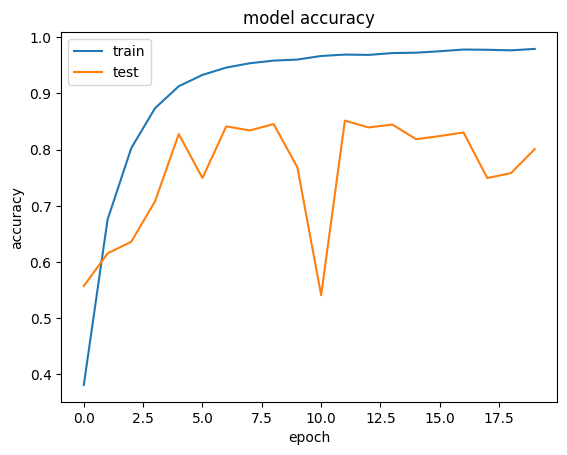

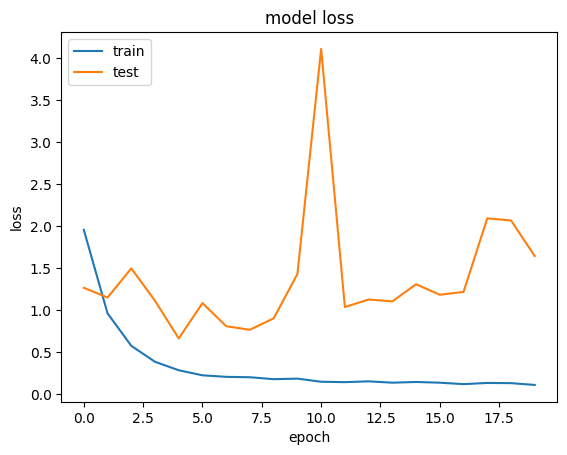

In [14]:
# Call the plot_history function we made and imported from helpers_plot_history.py

plot_history(history)

## How can we improve our model?

Honestly, that's not too bad with the data we have. About 80% accuracy for greyscale images 28X28 pixels seems remarkable to me! But, notice that the test accuracy is well below the training accuracy and test loss is going up or staying the same. We are overfitting our data.

We can do a number of things to improve on these results! Let's take a look.

Let's look at some slides that cover convolutional kernels, pooling, dropout and data augmentation for image classification in neural networks: [Lect_06_CNNs slides](https://docs.google.com/presentation/d/1uSk7xHWZ9H6YihUP4OdHpIVws_2py_HBfbby7GpZDCA/edit?usp=sharing)

Then, we can move to [part 2](17_CNNs_part2.ipynb) of this section.

In [ ]:
#Finished